# Computer Vision --- Lecture 4 Hands-On
## From Neural Networks to CNNs


We write backpropagation ourself: Forward pass, backward pass,
gradient check, for both a two-layer network and a convolution layer.

This is the last time we will do it by hand. From next week, autograd does it for us --
but only people who have done it once can debug it when it goes wrong.

| Section | Topic |
|---|---|
| 0 | Setup |
| 1 | Backprop on a scalar graph, and then on a real weight |
| 2 | Why the nonlinearity is not optional |
| 3 | A two-layer network in NumPy, with gradient checks |
| 4 | Training it, and looking inside |
| 5 | Measuring the vanishing gradient |
| 6 | The same network in PyTorch |
| 7 | A convolution layer from scratch |
| 8 | A first CNN |

Cells marked **TODO** are for you. Exercises at the end.

---
## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, load_digits
from sklearn.model_selection import train_test_split

np.set_printoptions(precision=4, suppress=True, linewidth=120)
plt.rcParams["figure.figsize"] = (10, 3.5)
rng = np.random.default_rng(0)

In [2]:
def softmax_loss(S, y):
    """Returns (loss, dL/dS). Same function as Lecture 3."""
    S = S - S.max(axis=1, keepdims=True)
    e = np.exp(S)
    p = e / e.sum(axis=1, keepdims=True)
    loss = -np.log(p[np.arange(len(y)), y] + 1e-12).mean()
    dS = p.copy()
    dS[np.arange(len(y)), y] -= 1
    return loss, dS / len(y)


def rel_error(a, b):
    return np.max(np.abs(a - b) / np.maximum(1e-12, np.abs(a) + np.abs(b)))


def numeric_grad(f, x, h=1e-5):
    """Centred finite differences over every entry of x."""
    grad = np.zeros_like(x, dtype=float)
    it = np.nditer(x, flags=["multi_index"], op_flags=["readwrite"])
    while not it.finished:
        i = it.multi_index
        old = x[i]
        x[i] = old + h; fp = f()
        x[i] = old - h; fm = f()
        x[i] = old
        grad[i] = (fp - fm) / (2 * h)
        it.iternext()
    return grad

---
## 1. Backprop on a Scalar Graph


Every node in a graph does the same two-step move. Writing $a$ for whatever goes **into** a
node and $u$ for whatever comes **out**:

$$\underbrace{\frac{\partial L}{\partial a}}_{\text{pass downstream}}
= \underbrace{\frac{\partial L}{\partial u}}_{\text{arrives from upstream}}
\cdot \underbrace{\frac{\partial u}{\partial a}}_{\text{the node's own derivative}}$$

$a$ is a **slot**, not a fixed quantity. At one node it holds the input image, at the next an
activation, at a third a **weight**. Only the last kind is what we are actually after -- we
minimise the loss over the *weights*, and the data is held constant -- but the node cannot tell
the difference and does not need to.

Because of that, we deliberately keep `x`, `y`, `z` for their course-wide meanings (input
image, label, pre-activation) and use neutral letters for toy graphs.

### 1a. Mechanics first, on neutral letters

$$f(a,b,c) = (a+b)\cdot c, \qquad a = -2,\; b = 5,\; c = -4$$

Do it on paper first. Then run the cell and check that you got the same four numbers.

In [3]:
a, b, c = -2.0, 5.0, -4.0

# ---- forward ----
q = a + b            # 3
f = q * c            # -12
print(f"forward:  q = {q},  f = {f}")

# ---- backward ----
df_df = 1.0
df_dq = c * df_df            # multiply gate: swap the other input
df_dc = q * df_df
df_da = df_dq * 1.0          # add gate: distribute unchanged
df_db = df_dq * 1.0

print(f"backward: df/da = {df_da},  df/db = {df_db},  df/dc = {df_dc}")

# ---- verify numerically ----
F = lambda p, q_, r: (p + q_) * r
h = 1e-6
print("\nnumerical check:")
print(f"  df/da = {(F(a+h,b,c) - F(a-h,b,c)) / (2*h):.6f}")
print(f"  df/db = {(F(a,b+h,c) - F(a,b-h,c)) / (2*h):.6f}")
print(f"  df/dc = {(F(a,b,c+h) - F(a,b,c-h)) / (2*h):.6f}")

forward:  q = 3.0,  f = -12.0
backward: df/da = -4.0,  df/db = -4.0,  df/dc = 3.0

numerical check:
  df/da = -4.000000
  df/db = -4.000000
  df/dc = 3.000000


### 1b. The same walk, on an actual weight

Nothing above involved a parameter, so nothing above could have trained anything. Now give the
letters their real jobs: one neuron with squared error,

$$L = \big(\sigma(wx + b) - y\big)^2, \qquad w = 0.5,\; x = 2,\; b = -0.3,\; y = 1$$

Here $x$ and $y$ are **data** and stay fixed; $w$ and $b$ are what we differentiate with
respect to. Same graph walk, same gate rules -- but the answers are now gradients you can
descend on.

In [4]:
w, x, b_, y = 0.5, 2.0, -0.3, 1.0        # b_ so we do not clobber b from 1a
sigmoid = lambda t: 1 / (1 + np.exp(-t))

# ---- forward ----
z    = w * x + b_                         # pre-activation
yhat = sigmoid(z)                         # prediction
L    = (yhat - y) ** 2                    # loss
print(f"forward:  z = {z:.4f}   yhat = {yhat:.4f}   L = {L:.4f}")

# ---- backward, right to left ----
dL_dyhat = 2 * (yhat - y)                 # square gate
dL_dz    = dL_dyhat * yhat * (1 - yhat)   # sigmoid gate: sigma(1 - sigma)
dL_dw    = dL_dz * x                      # multiply gate: swap -> the OTHER input
dL_db    = dL_dz * 1.0                    # add gate: pass through
dL_dx    = dL_dz * w                      # exists, but x is data: we never use it

print(f"backward: dL/dyhat = {dL_dyhat:.4f}   dL/dz = {dL_dz:.4f}")
print(f"          dL/dw    = {dL_dw:.6f}   dL/db = {dL_db:.6f}")
print(f"          dL/dx    = {dL_dx:.6f}   <- computed, then discarded")

# ---- verify numerically ----
loss_of = lambda ww, bb: (sigmoid(ww * x + bb) - y) ** 2
h = 1e-6
print("\nnumerical check:")
print(f"  dL/dw: numeric {(loss_of(w+h, b_) - loss_of(w-h, b_)) / (2*h):.6f}"
      f"   analytic {dL_dw:.6f}")
print(f"  dL/db: numeric {(loss_of(w, b_+h) - loss_of(w, b_-h)) / (2*h):.6f}"
      f"   analytic {dL_db:.6f}")

forward:  z = 0.7000   yhat = 0.6682   L = 0.1101
backward: dL/dyhat = -0.6636   dL/dz = -0.1471
          dL/dw    = -0.294268   dL/db = -0.147134
          dL/dx    = -0.073567   <- computed, then discarded

numerical check:
  dL/dw: numeric -0.294268   analytic -0.294268
  dL/db: numeric -0.147134   analytic -0.147134


Both gradients are negative, so gradient descent *increases* $w$ and $b$ -- which pushes
$\hat{y}$ up towards the label $y = 1$. That is the whole of learning, on one parameter.

Note the multiply gate did the useful work: $\partial L/\partial w = \partial L/\partial z \cdot x$.
The gradient on a weight is the upstream gradient scaled by **the input that weight multiplied**.
Large inputs therefore produce large weight gradients -- which is exactly why Lecture 3 insisted
on normalising the data, and why Lecture 5 will insist on BatchNorm.

**TODO 1.** In 1b the sigmoid was one node, using the shortcut
$\;\partial\sigma/\partial t = \sigma(1-\sigma)$. Redo it the long way: expand
$\sigma(t) = 1/(1+e^{-t})$ into five gates (negate, exponentiate, add-one, reciprocal, and the
$wx+b$ before them), propagate backwards one gate at a time, and confirm you land on the same
`dL_dw` and `dL_db`.

Then extend it to two inputs, $\;L = (\sigma(w_0x_0 + w_1x_1 + b) - y)^2\;$ with
$w = [2, -3]$, $x = [-1, -2]$, $b = -3$, $y = 1$, and gradient-check both weights. This is why
frameworks implement sigmoid as a *single* node rather than five -- you are about to feel the
difference.

In [5]:
# TODO 1 -- your code here
w_vec = np.array([2.0, -3.0])
x_vec = np.array([-1.0, -2.0])
# ...

---
## 2. The Nonlinearity Is Not Optional

Two identical networks on `make_circles`. The only difference: one applies ReLU to the
hidden layer, the other does not.

NO nonlinearity    accuracy 0.500
with ReLU          accuracy 1.000


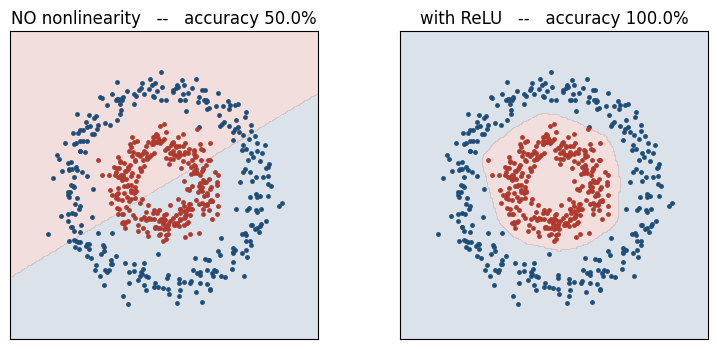

In [6]:
Xc, yc = make_circles(n_samples=600, factor=0.42, noise=0.10, random_state=0)

def train_2layer(X, y, H=32, iters=4000, lr=0.5, use_relu=True, seed=0):
    r = np.random.default_rng(seed)
    D, C = X.shape[1], int(y.max()) + 1
    W1 = r.standard_normal((H, D)) * np.sqrt(2 / D); b1 = np.zeros(H)
    W2 = r.standard_normal((C, H)) * np.sqrt(2 / H); b2 = np.zeros(C)
    for _ in range(iters):
        Z1 = X @ W1.T + b1
        Hh = np.maximum(0, Z1) if use_relu else Z1        # <-- the only difference
        S = Hh @ W2.T + b2
        _, dS = softmax_loss(S, y)
        dW2, db2 = dS.T @ Hh, dS.sum(0)
        dH = dS @ W2
        dZ1 = dH * (Z1 > 0) if use_relu else dH
        dW1, db1 = dZ1.T @ X, dZ1.sum(0)
        W1 -= lr * dW1; b1 -= lr * db1; W2 -= lr * dW2; b2 -= lr * db2

    def predict(Z):
        A = Z @ W1.T + b1
        return (np.maximum(0, A) if use_relu else A) @ W2.T + b2
    return predict


xx, yy = np.meshgrid(np.linspace(-1.6, 1.6, 220), np.linspace(-1.6, 1.6, 220))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
for ax, relu, name in [(axes[0], False, "NO nonlinearity"), (axes[1], True, "with ReLU")]:
    f = train_2layer(Xc, yc, use_relu=relu)
    Z = f(grid).argmax(1).reshape(xx.shape)
    acc = (f(Xc).argmax(1) == yc).mean()
    ax.contourf(xx, yy, Z, levels=[-.5, .5, 1.5], colors=["#1F4E79", "#B03A2E"], alpha=.16)
    ax.scatter(*Xc[yc == 0].T, s=6, c="#1F4E79")
    ax.scatter(*Xc[yc == 1].T, s=6, c="#B03A2E")
    ax.set_title(f"{name}   --   accuracy {acc:.1%}")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
    print(f"{name:18s} accuracy {acc:.3f}")
plt.tight_layout(); plt.show()

The network without a nonlinearity has 32 hidden units and thousands of parameters, and it
scores 50% -- chance. It is a linear model wearing a costume: $W_2(W_1x) = (W_2W_1)x$.

---
## 3. A Two-Layer Network, Properly

Now write it as a reusable pair of functions and **check both gradients**. This is the part
that matters: if the gradient is wrong the model still trains, just badly, and you will spend
a day blaming the learning rate.

In [7]:
def init_net(D, H, C, seed=0):
    r = np.random.default_rng(seed)
    return {"W1": r.standard_normal((H, D)) * np.sqrt(2 / D), "b1": np.zeros(H),
            "W2": r.standard_normal((C, H)) * np.sqrt(2 / H), "b2": np.zeros(C)}


def forward(p, X):
    Z1 = X @ p["W1"].T + p["b1"]
    H  = np.maximum(0, Z1)
    S  = H @ p["W2"].T + p["b2"]
    return S, (X, Z1, H)


def backward(p, cache, dS):
    X, Z1, H = cache
    grads = {}
    grads["W2"] = dS.T @ H
    grads["b2"] = dS.sum(axis=0)
    dH  = dS @ p["W2"]
    dZ1 = dH * (Z1 > 0)                 # ReLU: route where the input was positive
    grads["W1"] = dZ1.T @ X
    grads["b1"] = dZ1.sum(axis=0)
    return grads


def loss_and_grads(p, X, y):
    S, cache = forward(p, X)
    loss, dS = softmax_loss(S, y)
    return loss, backward(p, cache, dS)

In [8]:
# small problem so the numerical gradient is affordable
Xg = rng.standard_normal((12, 5))
yg = rng.integers(0, 3, 12)
pg = init_net(5, 7, 3)

loss, grads = loss_and_grads(pg, Xg, yg)
print(f"loss = {loss:.4f}\n")

for name in ["W1", "b1", "W2", "b2"]:
    ng = numeric_grad(lambda: loss_and_grads(pg, Xg, yg)[0], pg[name])
    err = rel_error(grads[name], ng)
    status = "PASS" if err < 1e-7 else ("suspicious" if err < 1e-4 else "FAIL")
    print(f"{name}: shape {str(grads[name].shape):10s} "
          f"relative error {err:.3e}   {status}")

loss = 1.6488

W1: shape (7, 5)     relative error 3.406e-09   PASS
b1: shape (7,)       relative error 2.254e-10   PASS
W2: shape (3, 7)     relative error 7.259e-10   PASS
b2: shape (3,)       relative error 1.054e-09   PASS


All four should come out below $10^{-8}$. If `W1` fails but `W2` passes, the bug is in the
ReLU backward step or in `dH` -- which is the usual place.

**TODO 2.** Break `backward` on purpose in three separate ways and record the relative error
each time:

1. drop the ReLU mask (use `dZ1 = dH`)
2. forget to transpose (`grads["W1"] = X.T @ dZ1` -- note this will also fail on shape)
3. use `>=` instead of `>` in the ReLU mask

The third one is interesting: predict what happens *before* you run it, then explain the result.

In [9]:
# TODO 2 -- your code here

---
## 4. Train It, Then Look Inside

validation accuracy: 0.9861
linear baseline:     0.9721   (the hidden layer is worth +0.0139)


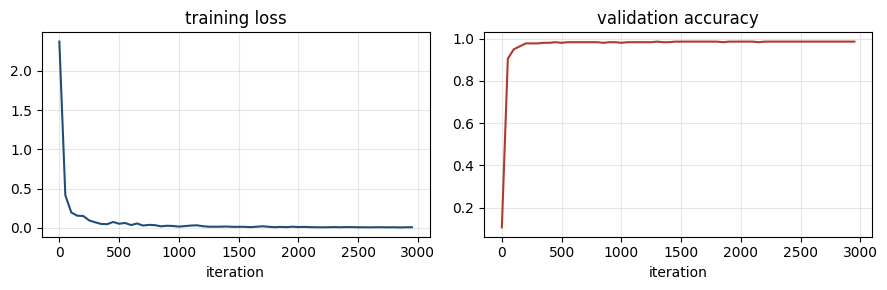

In [10]:
digits = load_digits()
Xd = digits.data / 16.0
yd = digits.target
Xtr, Xtmp, ytr, ytmp = train_test_split(Xd, yd, test_size=.4, random_state=0, stratify=yd)
Xva, Xte, yva, yte = train_test_split(Xtmp, ytmp, test_size=.5, random_state=0, stratify=ytmp)
mu = Xtr.mean(0)
Xtr, Xva, Xte = Xtr - mu, Xva - mu, Xte - mu

def train(p, X, y, Xv, yv, iters=3000, lr=0.3, batch=128, seed=0):
    r = np.random.default_rng(seed)
    hist = {"it": [], "loss": [], "val": []}
    for t in range(iters):
        i = r.choice(len(X), batch, replace=False)
        loss, g = loss_and_grads(p, X[i], y[i])
        for k in p:
            p[k] -= lr * g[k]
        if t % 50 == 0:
            hist["it"].append(t); hist["loss"].append(loss)
            hist["val"].append((forward(p, Xv)[0].argmax(1) == yv).mean())
    return hist

net = init_net(64, 64, 10)
h = train(net, Xtr, ytr, Xva, yva)
print(f"validation accuracy: {h['val'][-1]:.4f}")

# the Lecture 3 linear model, trained identically, for comparison
r = np.random.default_rng(0)
Wlin = 0.001 * r.standard_normal((10, 64))
for t in range(3000):
    i = r.choice(len(Xtr), 128, replace=False)
    _, dS = softmax_loss(Xtr[i] @ Wlin.T, ytr[i])
    Wlin -= 0.3 * (dS.T @ Xtr[i])
lin_acc = ((Xva @ Wlin.T).argmax(1) == yva).mean()
print(f"linear baseline:     {lin_acc:.4f}   "
      f"(the hidden layer is worth {h['val'][-1] - lin_acc:+.4f})")

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(h["it"], h["loss"], color="#1F4E79"); ax[0].set_title("training loss")
ax[1].plot(h["it"], h["val"], color="#B03A2E");  ax[1].set_title("validation accuracy")
for a in ax: a.grid(alpha=.3); a.set_xlabel("iteration")
plt.tight_layout(); plt.show()

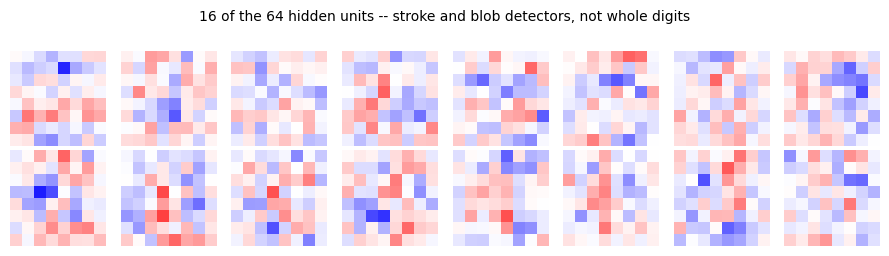

In [11]:
# what did the hidden units learn? each row of W1 has the shape of an image
lim = np.abs(net["W1"]).max()
fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(net["W1"][i].reshape(8, 8), cmap="bwr", vmin=-lim, vmax=lim)
    ax.axis("off")
plt.suptitle("16 of the 64 hidden units -- stroke and blob detectors, not whole digits",
             fontsize=10)
plt.tight_layout(); plt.show()

Compare these with the Lecture 3 templates. The linear model had to make each row look like
an entire digit. These units look like *parts* -- strokes, curves, blobs -- because the second
layer is free to combine them. That is the whole argument for depth, visible in one picture.

---
## 5. Measuring the Vanishing Gradient

Build a deep MLP, run one backward pass, and record $\|\partial L/\partial W\|$ at every layer.
Nothing here is trained -- we only care about whether the signal survives the trip backwards.

sigmoid   layer 1 / layer 12 = 7.68e-08
tanh      layer 1 / layer 12 = 9.99e-01
relu      layer 1 / layer 12 = 1.41e+00


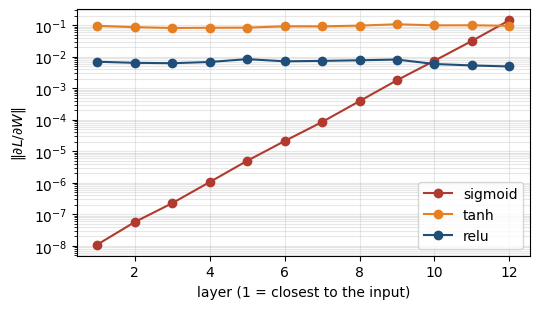

In [12]:
def gradient_by_layer(act, n_layers=12, width=64, N=256, seed=1):
    r = np.random.default_rng(seed)
    X = r.standard_normal((N, width))
    y = r.integers(0, 10, N)
    Ws = [r.standard_normal((width, width)) * np.sqrt(1 / width) for _ in range(n_layers)]
    Wout = r.standard_normal((10, width)) * np.sqrt(1 / width)

    acts, pre, hh = [X], [], X
    for W in Ws:
        z = hh @ W.T
        pre.append(z)
        hh = {"sigmoid": lambda t: 1 / (1 + np.exp(-t)),
              "tanh": np.tanh,
              "relu": lambda t: np.maximum(0, t)}[act](z)
        acts.append(hh)

    _, dS = softmax_loss(hh @ Wout.T, y)
    dh, norms = dS @ Wout, []
    for i in range(n_layers - 1, -1, -1):
        z = pre[i]
        if act == "sigmoid":
            s = 1 / (1 + np.exp(-z)); dz = dh * s * (1 - s)
        elif act == "tanh":
            dz = dh * (1 - np.tanh(z) ** 2)
        else:
            dz = dh * (z > 0)
        norms.append(np.linalg.norm(dz.T @ acts[i]))
        dh = dz @ Ws[i]
    return norms[::-1]


plt.figure(figsize=(5.5, 3.2))
for act, col in [("sigmoid", "#B03A2E"), ("tanh", "#E67E22"), ("relu", "#1F4E79")]:
    n = gradient_by_layer(act)
    plt.semilogy(range(1, 13), n, "o-", color=col, label=act)
    print(f"{act:8s}  layer 1 / layer 12 = {n[0]/n[-1]:.2e}")
plt.xlabel("layer (1 = closest to the input)")
plt.ylabel(r"$\|\partial L / \partial W\|$")
plt.legend(); plt.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

Sigmoid loses seven orders of magnitude over twelve layers -- close to the $4^{-12}$ the
lecture predicted. The first layer receives essentially nothing and never learns.

Note that tanh survives here, because these weights are initialized to preserve variance
($\sqrt{1/\text{width}}$). Try changing that scale to `0.01` and rerun: tanh collapses too.
Initialization and activation interact, which is exactly why Week 5 spends time on it.

---
## 6. The Same Network in PyTorch

*(Needs `torch`. Skip if not installed.)*

In [13]:
import torch
import torch.nn as nn

Xt = torch.tensor(Xtr, dtype=torch.float32)
yt = torch.tensor(ytr, dtype=torch.long)
Xv = torch.tensor(Xva, dtype=torch.float32)
yv = torch.tensor(yva, dtype=torch.long)

torch.manual_seed(0)
model = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 10))
opt = torch.optim.SGD(model.parameters(), lr=0.3)
lossf = nn.CrossEntropyLoss()

for t in range(3000):
    i = torch.randint(0, len(Xt), (128,))
    opt.zero_grad()                       # <-- gradients accumulate without this
    lossf(model(Xt[i]), yt[i]).backward()
    opt.step()

with torch.no_grad():
    print(f"PyTorch validation accuracy: {(model(Xv).argmax(1) == yv).float().mean():.4f}")
print(f"NumPy   validation accuracy: {h['val'][-1]:.4f}")

PyTorch validation accuracy: 0.9805
NumPy   validation accuracy: 0.9861


In [14]:
# autograd computes the same gradients you derived in section 3
p2 = {"W1": model[0].weight.detach().numpy().copy(),
      "b1": model[0].bias.detach().numpy().copy(),
      "W2": model[2].weight.detach().numpy().copy(),
      "b2": model[2].bias.detach().numpy().copy()}

model.zero_grad()
lossf(model(Xt[:64]), yt[:64]).backward()
_, mine = loss_and_grads(p2, Xtr[:64], ytr[:64])

for name, param in [("W1", model[0].weight), ("b1", model[0].bias),
                    ("W2", model[2].weight), ("b2", model[2].bias)]:
    print(f"{name}: max |torch - mine| = "
          f"{np.abs(param.grad.numpy() - mine[name]).max():.3e}")

W1: max |torch - mine| = 1.150e-08
b1: max |torch - mine| = 1.645e-08
W2: max |torch - mine| = 2.495e-08
b2: max |torch - mine| = 1.091e-08


### The `zero_grad` trap

Gradients **accumulate** into `.grad` -- because a value used twice must sum its gradients.
Remove `opt.zero_grad()` from the loop above and training does not crash; it silently uses
the sum of every gradient so far. Try it once so you recognize the symptom.

---
## 7. A Convolution Layer From Scratch

Naive loops first, then the `im2col` version everyone actually uses, then the backward pass
with a gradient check.

In [15]:
def conv_naive(X, W, b, pad=1):
    """X: (N,C,H,Wd)  W: (F,C,k,k)  ->  (N,F,H',W')"""
    N, C, H, Wd = X.shape
    F, _, k, _ = W.shape
    Xp = np.pad(X, ((0, 0), (0, 0), (pad, pad), (pad, pad)))
    Ho, Wo = H + 2 * pad - k + 1, Wd + 2 * pad - k + 1
    out = np.zeros((N, F, Ho, Wo))
    for n in range(N):
        for f in range(F):
            for i in range(Ho):
                for j in range(Wo):
                    out[n, f, i, j] = np.sum(Xp[n, :, i:i+k, j:j+k] * W[f]) + b[f]
    return out


def im2col(X, k, pad):
    N, C, H, Wd = X.shape
    Xp = np.pad(X, ((0, 0), (0, 0), (pad, pad), (pad, pad)))
    Ho, Wo = H + 2 * pad - k + 1, Wd + 2 * pad - k + 1
    cols = np.empty((N, C * k * k, Ho * Wo))
    idx = 0
    for c in range(C):
        for u in range(k):
            for v in range(k):
                cols[:, idx, :] = Xp[:, c, u:u+Ho, v:v+Wo].reshape(N, -1)
                idx += 1
    return cols, Ho, Wo


def conv_forward(X, W, b, pad=1):
    """The whole convolution as one matrix product."""
    N, k = X.shape[0], W.shape[-1]
    cols, Ho, Wo = im2col(X, k, pad)
    out = np.einsum("oj,njp->nop", W.reshape(W.shape[0], -1), cols) + b[None, :, None]
    return out.reshape(N, W.shape[0], Ho, Wo), (X, W, cols, Ho, Wo, pad)

In [16]:
Xs = rng.standard_normal((2, 3, 8, 8))
Ws = rng.standard_normal((4, 3, 3, 3)) * 0.2
bs = rng.standard_normal(4) * 0.1

o_naive = conv_naive(Xs, Ws, bs, pad=1)
o_fast, cache = conv_forward(Xs, Ws, bs, pad=1)

print("output shape:", o_fast.shape)
print("naive vs im2col, max |difference|:", np.abs(o_naive - o_fast).max())

# the output-size formula from the lecture
for H, k, s, p in [(224, 7, 2, 3), (32, 3, 1, 1), (28, 5, 1, 0), (14, 3, 2, 1)]:
    print(f"H={H:3d} k={k} s={s} p={p}  ->  {(H + 2*p - k)//s + 1}")

output shape: (2, 4, 8, 8)
naive vs im2col, max |difference|: 8.881784197001252e-16
H=224 k=7 s=2 p=3  ->  112
H= 32 k=3 s=1 p=1  ->  32
H= 28 k=5 s=1 p=0  ->  24
H= 14 k=3 s=2 p=1  ->  7


In [17]:
def conv_backward(dout, cache):
    X, W, cols, Ho, Wo, pad = cache
    N, C, H, Wd = X.shape
    F, _, k, _ = W.shape
    dflat = dout.reshape(N, F, -1)

    dW = np.einsum("nop,njp->oj", dflat, cols).reshape(W.shape)
    db = dflat.sum(axis=(0, 2))

    dcols = np.einsum("oj,nop->njp", W.reshape(F, -1), dflat)
    dXp = np.zeros((N, C, H + 2*pad, Wd + 2*pad))
    idx = 0
    for c in range(C):
        for u in range(k):
            for v in range(k):
                dXp[:, c, u:u+Ho, v:v+Wo] += dcols[:, idx, :].reshape(N, Ho, Wo)
                idx += 1
    dX = dXp[:, :, pad:pad+H, pad:pad+Wd] if pad else dXp
    return dX, dW, db


# gradient check: use a scalar objective sum(out * random_weights)
Xs = rng.standard_normal((2, 2, 6, 6))
Ws = rng.standard_normal((3, 2, 3, 3)) * 0.2
bs = rng.standard_normal(3) * 0.1
R = rng.standard_normal((2, 3, 6, 6))

def objective():
    return (conv_forward(Xs, Ws, bs, 1)[0] * R).sum()

out, cache = conv_forward(Xs, Ws, bs, 1)
dX, dW, db = conv_backward(R, cache)

for name, arr, ana in [("X", Xs, dX), ("W", Ws, dW), ("b", bs, db)]:
    ng = numeric_grad(objective, arr)
    err = rel_error(ana, ng)
    print(f"d{name}: relative error {err:.3e}   {'PASS' if err < 1e-7 else 'FAIL'}")

dX: relative error 5.927e-09   PASS
dW: relative error 3.916e-10   PASS
db: relative error 8.563e-12   PASS


Notice what `conv_backward` is doing. `dW` correlates the input with the upstream gradient
and **sums over every spatial position** -- because one filter was used at every position, and
gradients add when a value is reused. `dX` scatters the gradient back into the positions each
input contributed to, which is a full convolution with the flipped kernel.

**TODO 3.** Extend `conv_forward` to support a **stride** parameter, and verify the output
size against $\lfloor (H + 2p - k)/s \rfloor + 1$ for at least four configurations.
Then check your gradient still passes -- stride is where most hand-written conv
implementations break.

In [18]:
# TODO 3 -- your code here
def conv_forward_strided(X, W, b, pad=1, stride=1):
    ...

---
## 8. A First CNN

`[conv -> ReLU -> pool] x 2 -> fully connected` on digits. LeNet-5, shrunk.

*(Needs `torch`.)*

In [19]:
import torch.nn.functional as F

Xi = torch.tensor(digits.data / 16.0, dtype=torch.float32).reshape(-1, 1, 8, 8)
yi = torch.tensor(digits.target, dtype=torch.long)
n_tr = 1300
Xtr_t, ytr_t, Xte_t, yte_t = Xi[:n_tr], yi[:n_tr], Xi[n_tr:], yi[n_tr:]

torch.manual_seed(0)
cnn = nn.Sequential(
    nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 8 x 4 x 4
    nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 16 x 2 x 2
    nn.Flatten(), nn.Linear(16 * 2 * 2, 10))

n_params = sum(p.numel() for p in cnn.parameters())
print(f"parameters: {n_params:,}")
for name, p in cnn.named_parameters():
    print(f"  {name:14s} {tuple(p.shape)}  {p.numel():,}")

opt = torch.optim.SGD(cnn.parameters(), lr=0.1, momentum=0.9)
for epoch in range(30):
    perm = torch.randperm(n_tr)
    for i in range(0, n_tr, 64):
        idx = perm[i:i+64]
        opt.zero_grad()
        F.cross_entropy(cnn(Xtr_t[idx]), ytr_t[idx]).backward()
        opt.step()

with torch.no_grad():
    print(f"\ntest accuracy: {(cnn(Xte_t).argmax(1) == yte_t).float().mean():.4f}")

parameters: 1,898
  0.weight       (8, 1, 3, 3)  72
  0.bias         (8,)  8
  3.weight       (16, 8, 3, 3)  1,152
  3.bias         (16,)  16
  7.weight       (10, 64)  640
  7.bias         (10,)  10

test accuracy: 0.9296


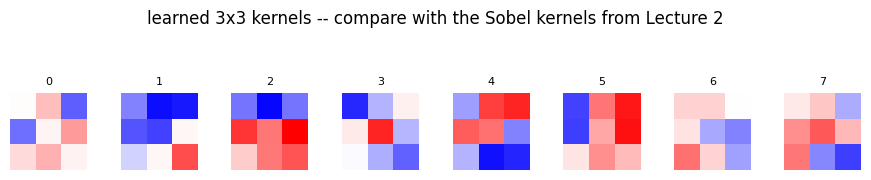

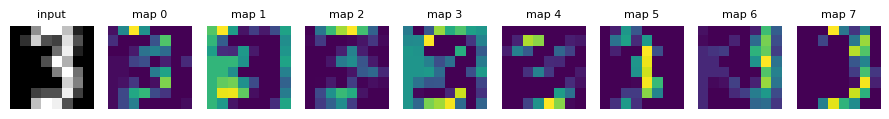

In [20]:
# the learned first-layer kernels
K = cnn[0].weight.detach().numpy()
lim = np.abs(K).max()
fig, axes = plt.subplots(1, 8, figsize=(9, 1.4))
for i, ax in enumerate(axes):
    ax.imshow(K[i, 0], cmap="bwr", vmin=-lim, vmax=lim)
    ax.set_title(f"{i}", fontsize=8); ax.axis("off")
plt.suptitle("learned 3x3 kernels -- compare with the Sobel kernels from Lecture 2", y=1.25)
plt.tight_layout(); plt.show()

# and the activation maps they produce
with torch.no_grad():
    a1 = cnn[1](cnn[0](Xte_t[:1]))
fig, axes = plt.subplots(1, 9, figsize=(9, 1.4))
axes[0].imshow(Xte_t[0, 0], cmap="gray"); axes[0].set_title("input", fontsize=8)
for i in range(8):
    axes[i+1].imshow(a1[0, i], cmap="viridis"); axes[i+1].set_title(f"map {i}", fontsize=8)
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()

---
## Exercises

**1. Dying ReLU, observed.** Train the two-layer network on digits at learning rates
$\{0.1, 1, 5, 20\}$. After each run, count how many hidden units output zero for *every*
training example. Plot that count against learning rate, and against training iteration for
the worst case. Then swap ReLU for Leaky ReLU and repeat -- does the problem disappear, and
does accuracy improve or just the diagnostic?

**2. Width vs depth, at fixed budget.** Build three networks with roughly the same parameter
count: one hidden layer of 256 units, two of 90, four of 55. Train all three on digits with
identical settings. Report accuracy and training time. Then repeat on a harder problem
(`make_moons` with `noise=0.35`, or digits with 20% label noise). Does depth help more when
the problem is harder?

**3. Initialization matters.** Initialize `W1` and `W2` with `scale * randn` for
`scale` in $\{0.001, 0.01, 0.1, \sqrt{2/D}\}$ and plot the training curves. Then reproduce the
section 5 gradient measurement for each. Explain the connection between the two plots --
this is the entire motivation for He initialization, which you will meet formally in Week 5.

**4. Receptive field, measured not derived.** Take the trained CNN, pick one unit in the
second conv layer, and find its receptive field empirically: perturb each input pixel in turn
and record which perturbations change that unit's output. Compare the measured region against
the $5\times5$ the lecture predicts. Then do the same for a unit *after* the first pooling
layer and explain the difference.

**5. Conv vs FC on shifted data.** Train (a) a two-layer MLP and (b) the small CNN on digits.
Then evaluate both on a test set where every image is shifted by one pixel
(`np.roll(X, 1, axis=-1)`). Report both accuracy drops. The gap is translation equivariance,
measured in a single number -- and it is the reason the second half of this lecture exists.